In [1]:
from codebase.utils_ml import *

In [2]:
features_memmap = np.load('features_extracted_8_sim.npy', mmap_mode='r')

# features_memmap = np.load('data/features_filtered.npy', mmap_mode='r')
old_label_arr = np.array([np.tile(i,3000) for i in np.arange(0,8)]).flatten()

# Define the mapping from class labels (0 to 7) to the new 3-element array format
# where each element in the array represents the number of poles on [bt], [bb], and [tb]
class_to_poles = {
    0: [1, 0, 0],  # 1 pole on [bt]
    1: [0, 1, 0],  # 1 pole on [bb]
    2: [0, 0, 1],  # 1 pole on [tb]
    3: [1, 1, 0],  # 1 pole on [bt] and 1 pole on [bb]
    4: [0, 1, 1],  # 1 pole on [bb] and 1 pole on [tb]
    5: [1, 1, 1],  # 1 pole on each of [bt], [bb], and [tb]
    6: [0, 2, 1],  # 2 poles on [bb] and 1 pole on [tb]
    7: [0, 1, 2]   # 1 pole on [bb] and 2 poles on [tb]
}

new_label_arr = convert_labels(old_label_arr, class_to_poles)

X_train, X_test, y_train, y_test = train_test_split(features_memmap, new_label_arr, test_size=0.1, random_state=42)

In [3]:
# Train Pool for CatBoost (multi-output regression requires separate models per target)
models = []
preds = []
data_uncertainty = []
knowledge_uncertainty = []

for i in range(y_train.shape[1]):
    train_pool = Pool(X_train, y_train[:, i])
    val_pool = Pool(X_test, y_test[:, i])

    model = CatBoostRegressor(
    iterations=50,             # Reduce iterations
    loss_function='RMSEWithUncertainty',
    random_seed=0,
    verbose=100,
    early_stopping_rounds=10,    # Stop early if no improvement
    depth=3
        )
    model.fit(train_pool, eval_set=val_pool, use_best_model=False)
    models.append(model)

    # Generate predictions with uncertainty
    pred = model.virtual_ensembles_predict(X_test, prediction_type='TotalUncertainty', virtual_ensembles_count=10)
    preds.append(pred[:, 0])  # Mean predictions
    data_uncertainty.append(pred[:, 2])  # Data uncertainty
    knowledge_uncertainty.append(pred[:, 1])  # Knowledge uncertainty

# Convert lists to arrays for easier manipulation
preds = np.column_stack(preds)
data_uncertainty = np.column_stack(data_uncertainty)
knowledge_uncertainty = np.column_stack(knowledge_uncertainty)

0:	learn: 0.6741820	test: 0.6628568	best: 0.6628568 (0)	total: 63.4ms	remaining: 3.1s
49:	learn: 0.0729115	test: 0.0686074	best: 0.0686074 (49)	total: 812ms	remaining: 0us

bestTest = 0.06860737318
bestIteration = 49

0:	learn: 0.8595168	test: 0.8534074	best: 0.8534074 (0)	total: 12.1ms	remaining: 591ms
49:	learn: 0.1555646	test: 0.1514961	best: 0.1514961 (49)	total: 689ms	remaining: 0us

bestTest = 0.1514960638
bestIteration = 49

0:	learn: 0.9934976	test: 1.0004083	best: 1.0004083 (0)	total: 12.4ms	remaining: 608ms
49:	learn: 0.6070261	test: 0.6051469	best: 0.6051469 (49)	total: 657ms	remaining: 0us

bestTest = 0.6051468603
bestIteration = 49



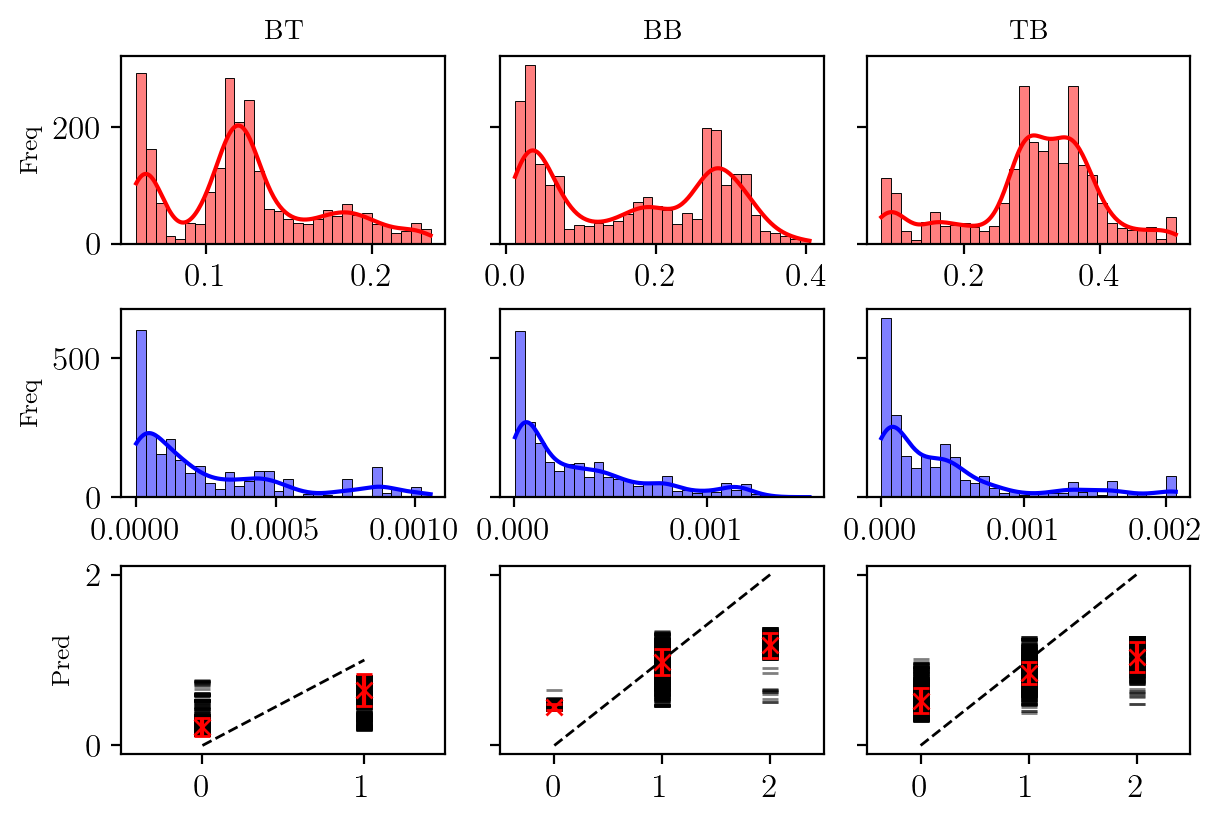

In [4]:
plot_uncer(preds, y_test, data_uncertainty, knowledge_uncertainty)

# Uncer vs MSE

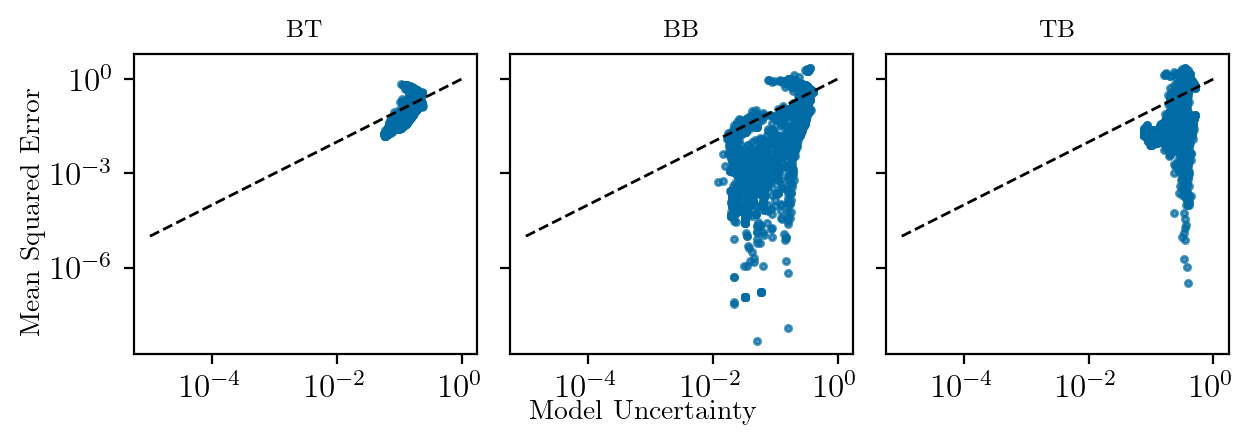

In [5]:
plot_uncer_against_exact(preds, y_test, data_uncertainty)

# Acc

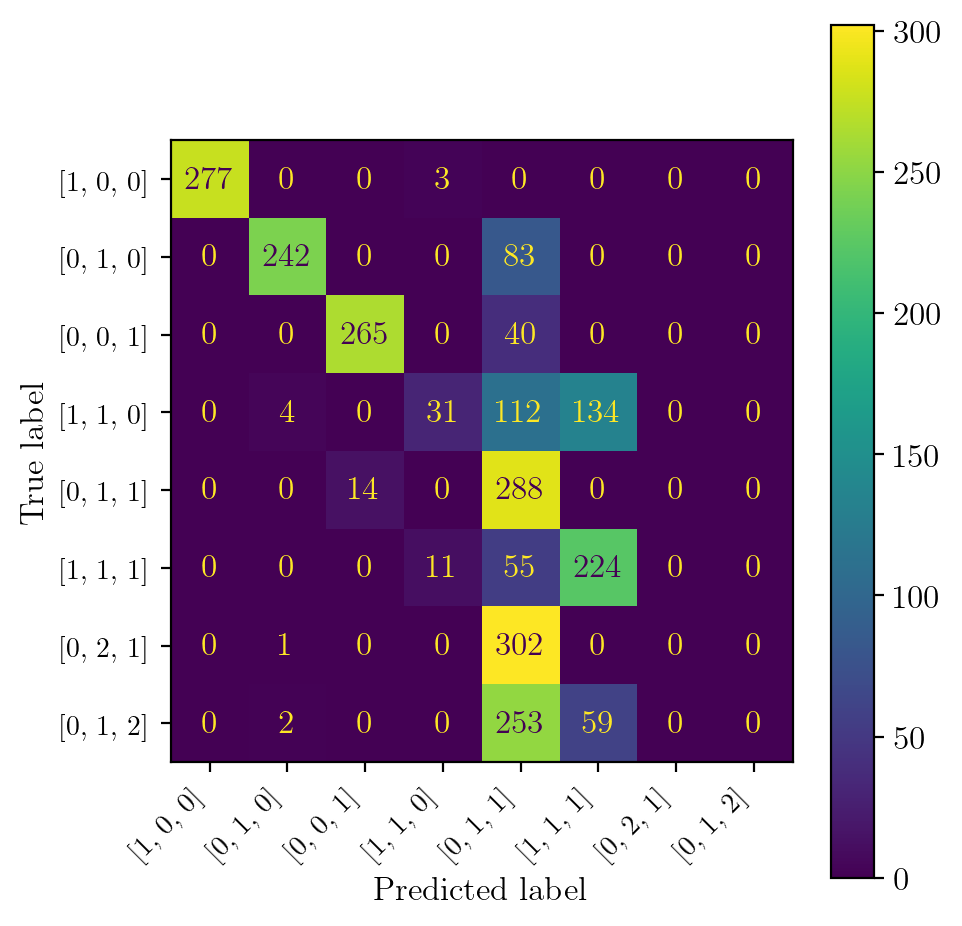

In [6]:
predictions_converted = reconvert_labels(np.abs(np.round(preds)).tolist(), class_to_poles)
mean_predictions = np.round(np.array(predictions_converted))

plot_cm(reconvert_labels(y_test, class_to_poles), mean_predictions, class_to_poles)

# Define Bounds with 95% certainty

In [7]:
confidence_multiplier = 1.96 # Assuming a certain confidence level, adjust as necessary
for i in range(3):
    lower_bound = (preds[:,i] - confidence_multiplier * np.sqrt(data_uncertainty[:,i]))
    upper_bound = (preds[:,i] + confidence_multiplier * np.sqrt(data_uncertainty[:,i]))

    # Coverage calculation
    covered = np.sum((y_test[:,i] >= lower_bound) & (y_test[:,i] <= upper_bound))
    coverage = covered / len(y_test)
    print("Check if coverage makes sense:", coverage)

Check if coverage makes sense: 0.9783333333333334
Check if coverage makes sense: 0.9579166666666666
Check if coverage makes sense: 0.98


In [9]:
# Train Pool for CatBoost (multi-output regression requires separate models per target)
X_exp = np.load("features_extracted_8_exp.npy")
preds_exp = []
data_uncertainty_exp = []
knowledge_uncertainty_exp = []
lower_bound_arr = []
upper_bound_arr = []

for i in range(y_train.shape[1]):
    
    # Generate predictions with uncertainty
    pred = models[i].virtual_ensembles_predict(X_exp, prediction_type='TotalUncertainty', virtual_ensembles_count=10)
    preds_exp.append(pred[:, 0])  # Mean predictions
    data_uncertainty_exp.append(pred[:, 2])  # Data uncertainty
    knowledge_uncertainty_exp.append(pred[:, 1])  # Knowledge uncertainty

    lower_bound_arr.append( (pred[:,0] - confidence_multiplier * np.sqrt(pred[:,2])))
    upper_bound_arr.append( (pred[:,0] + confidence_multiplier * np.sqrt(pred[:,2])))

# Convert lists to arrays for easier manipulation
preds_exp = np.column_stack(preds_exp)
data_uncertainty_exp = np.column_stack(data_uncertainty_exp)
knowledge_uncertainty_exp = np.column_stack(knowledge_uncertainty_exp)
lower_bound_arr = np.column_stack(lower_bound_arr)
upper_bound_arr = np.column_stack(upper_bound_arr)

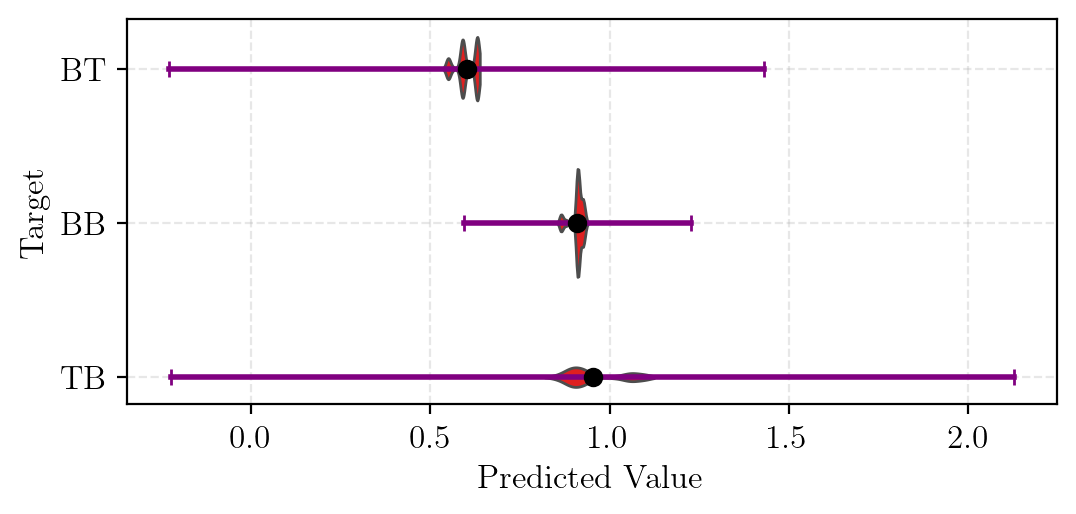

In [10]:
targets = ["BT", "BB", "TB"]

# Convert to DataFrame
df = pd.DataFrame({
    "Target": np.tile(targets, preds_exp.shape[0] ),
    "Predicted": preds_exp.flatten(),
    "Lower Bound": lower_bound_arr.flatten(),
    "Upper Bound": upper_bound_arr.flatten(),
})

plot_predictions_with_confidence(df)

In [11]:
# fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # 3 subplots in a row

# for i, ax in enumerate(axes):
   
#     sns.kdeplot(preds_exp[:, i], label='Predicted', fill=True, color='red', alpha=0.5, ax=ax)
#     sns.kdeplot(lower_bound_arr[:, i], label='Lower Bound', color='green', linestyle='--', alpha=0.7, ax=ax)
#     sns.kdeplot(upper_bound_arr[:, i], label='Upper Bound', color='purple', linestyle='--', alpha=0.7, ax=ax)

#     ax.set_xlabel('Predicted Value')
#     ax.set_ylabel('Density')
   
    
#     ax.set_xlim([0,2])
# ax.legend()
# axes[0].set_title("bt")
# axes[1].set_title("bb")
# axes[2].set_title("tb")

# plt.tight_layout()
# plt.show()

In [12]:

# Define class boundaries
class_boundaries = np.array([0.5, 1.5])  # Boundaries between classes 0-1 and 1-2

# Compute likelihoods for each position (bt, bb, tb)
likelihoods = {
    "bt": compute_class_probabilities(lower_bound_arr[:,0], upper_bound_arr[:, 0], class_boundaries),
    "bb": compute_class_probabilities(lower_bound_arr[:,1], upper_bound_arr[:, 1], class_boundaries),
    "tb": compute_class_probabilities(lower_bound_arr[:,2], upper_bound_arr[:, 2], class_boundaries)
}

# Convert to DataFrame
likelihoods_df = pd.DataFrame(likelihoods, index=["Class 0", "Class 1", "Class 2"])

# Display likelihoods
print(likelihoods_df)


               bt        bb        tb
Class 0  0.438959  0.000022  0.307935
Class 1  0.561041  0.999855  0.425639
Class 2  0.000000  0.000123  0.266427


# Training Threshold

In [13]:
# preds_train = []
# data_uncertainty_train = []
# knowledge_uncertainty_train = []

# preds_test = []
# data_uncertainty_test = []
# knowledge_uncertainty_test = []

# for i in range(y_train.shape[1]):
#     train_pool = Pool(X_train, y_train[:, i])
#     val_pool = Pool(X_test, y_test[:, i])

#     model = models[i]

#     # Generate predictions with uncertainty
#     pred_train = model.virtual_ensembles_predict(X_train, prediction_type='TotalUncertainty', virtual_ensembles_count=10)
#     preds_train.append(pred_train[:, 0])  # Mean predictions
#     data_uncertainty_train.append(pred_train[:, 2])  # Data uncertainty
#     knowledge_uncertainty_train.append(pred_train[:, 1])  # Knowledge uncertainty

#     pred_test = model.virtual_ensembles_predict(X_test, prediction_type='TotalUncertainty', virtual_ensembles_count=10)
#     preds_test.append(pred_test[:, 0])  # Mean predictions
#     data_uncertainty_test.append(pred_test[:, 2])  # Data uncertainty
#     knowledge_uncertainty_test.append(pred_test[:, 1])  # Knowledge uncertainty

# # Convert lists to arrays for easier manipulation
# preds_train = np.column_stack(preds_train)
# data_uncertainty_train = np.column_stack(data_uncertainty_train)
# knowledge_uncertainty_train = np.column_stack(knowledge_uncertainty_train)

# preds_test = np.column_stack(preds_test)
# data_uncertainty_test = np.column_stack(data_uncertainty_test)
# knowledge_uncertainty_test = np.column_stack(knowledge_uncertainty_test)

In [14]:
# optimized_thresholds = optimize_thresholds(preds_train, y_train, class_to_poles)
# print("Optimized Thresholds:", optimized_thresholds)

In [15]:
# adjusted_preds_train = round_with_thresholds(preds_train, optimized_thresholds, class_to_poles)

# res_ = np.sum(np.sum(np.round(preds_train) == y_train, axis=1) == 3)/y_train.shape[0]
# print(f"Test Accuracy Baselie: {np.mean(res_):.4f}")

# res_ = np.sum(np.sum(adjusted_preds_train == y_train, axis=1) == 3)/y_train.shape[0]
# print(f"Test Accuracy Improved: {np.mean(res_):.4f}")

In [16]:
# adjusted_preds = round_with_thresholds(preds, optimized_thresholds, class_to_poles)

# res_ = np.sum(np.sum(np.round(preds) == y_test, axis=1) == 3)/y_test.shape[0]
# print(f"Test Accuracy Baselie: {np.mean(res_):.4f}")

# res_ = np.sum(np.sum(adjusted_preds == y_test, axis=1) == 3)/y_test.shape[0]
# print(f"Test Accuracy: {np.mean(res_):.4f}")

In [17]:
# Test Accuracy Baselie: 0.9281
# Test Accuracy Improved: 0.9326

# Test Accuracy Baselie: 0.8554
# Test Accuracy Improved: 0.8638

# Removing

In [18]:
# # Sort the data by uncertainty for each target
# mse_changes = []
# percent_removed = []

# for i in range(y_train.shape[1]):
#     sorted_indices = np.argsort(data_uncertainty[:, i])[::-1] 
#     sorted_uncertainties = data_uncertainty[sorted_indices, i]
#     sorted_true = y_test[sorted_indices, i]
#     sorted_preds = preds[sorted_indices, i]

#     # Calculate the MSE after removing samples with the highest uncertainty
#     acc_list = []
#     percent_list = []
#     total_samples = len(sorted_uncertainties)

#     for remove_percent in range(0, 101, 5):  # Remove in 5% increments
#         num_remove = int(total_samples * (remove_percent / 100))
#         remaining_true = sorted_true[num_remove:]
#         remaining_preds = sorted_preds[num_remove:]

#         # mse = np.mean((remaining_true - remaining_preds) ** 2)  # Calculate MSE
#         acc = np.sum(remaining_true == np.round(remaining_preds)) /remaining_preds.shape[0]
#         acc_list.append(acc)
#         percent_list.append(remove_percent)
        

#     mse_changes.append(acc_list)
#     percent_removed.append(percent_list)

# # Plot the results
# # plt.figure(figsize=(15, 5))
# fig, axs = plt.subplots(1,figsize=(3.54331, 3.54331*0.75))

# for i in range(y_train.shape[1]):
#     axs.plot(percent_removed[i], mse_changes[i],"-o", label=f"Pole Idx {i+1}")
# axs.set_xlabel("Percentage of Rejected Samples")
# axs.set_ylabel("Accuracy")
# # axs.set_title("Impact of Removing High-Uncertainty Samples on Acc")
# axs.legend()
# axs.set_xticks([0, 20, 40, 60, 80, 100])
# axs.set_xticklabels([f"{int(p)}\%" for p in [0, 20, 40, 60, 80, 100]])
# axs.grid(True)
# fig.tight_layout()
# # fig.show()

# Hist

In [19]:
# # Number of classes
# num_classes = 8
# custom_labels = [str(class_to_poles[i]) for i in range(len(class_to_poles))]
# # Initialize an array to store accuracies for each class across folds
# class_accuracies= []
# class_uncer = []


# for cls in range(num_classes):
#     # Mask for the current class
    
#     class_mask = (reconvert_labels(y_test, class_to_poles) == cls)
#     # Calculate accuracy for the current fold and class
#     # /np.sum(np.ones_like(y_test[:,0]))
#     class_accuracy = np.sum(np.sum(adjusted_preds[class_mask]==y_test[class_mask],axis=1) == 3) / np.sum(class_mask)
#     class_accuracies.append(class_accuracy)

#     class_u = np.mean(data_uncertainty_test[class_mask])
#     class_uncer.append(class_u)

# class_accuracies = np.array(class_accuracies)
# class_uncer = np.array(class_uncer)
# # Bar plot with error bars
# sorted_indices = np.argsort(class_accuracies)[::-1]
# sorted_means = class_accuracies[sorted_indices]
# sorted_stds = class_uncer[sorted_indices]
# sorted_labels = [str(class_to_poles[i]) for i in sorted_indices]

# # Plotting
# fig, ax = plt.subplots(figsize=(3.54331, 3.54331*0.75))
# ax.bar(range(num_classes), sorted_means, yerr=sorted_stds, capsize=5)
# ax.set_ylabel('Accuracy')

# ax.set_xticks(np.arange(len(sorted_labels)))
# ax.set_xticklabels(sorted_labels, rotation=45, ha='right', fontsize=10)
# ax.set_ylim(0,1)
# # Adjust layout and show the plot
# plt.tight_layout()
# plt.show()

In [20]:
# custom_labels = [str(class_to_poles[i]) for i in range(len(class_to_poles))]

# # Compute the confusion matrix
# predictions = reconvert_labels(np.abs(np.round(preds)).tolist(), class_to_poles)
# cm = confusion_matrix(reconvert_labels(y_test, class_to_poles), predictions, labels=np.arange(len(class_to_poles)))

# # Plot the confusion matrix
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(len(class_to_poles)))
# fig, ax = plt.subplots(figsize=(5, 5))  # Adjust figure size if needed
# disp.plot(ax=ax)

# # Update x and y axis tick labels with the custom labels
# ax.set_xticks(np.arange(len(custom_labels)))
# ax.set_yticks(np.arange(len(custom_labels)))
# ax.set_xticklabels(custom_labels, rotation=45, ha='right', fontsize=10)
# ax.set_yticklabels(custom_labels, fontsize=10)

# # Adjust layout for readability
# plt.tight_layout()
# plt.show()

# Anomaly detection

In [21]:
# ext_old_label_arr = np.array([np.tile(i,np.load(f"{'dataExt/P'}{0:02d}{'_intensity.pkl'}", allow_pickle=True).shape[0]) for i in np.arange(35)]).flatten()
# ext_class_to_poles = {
#     0: [0, 0, 0],  # 1 pole on [bt]
#     1: [1, 0, 0],  # 1 pole on [bb]
#     2: [0, 1, 0],  # 1 pole on [tb]
#     3: [0, 0, 1],  # 1 pole on [bt] and 1 pole on [bb]
#     4: [2, 0, 0],  # 1 pole on [bb] and 1 pole on [tb]
#     5: [0, 2, 0],  # 1 pole on each of [bt], [bb], and [tb]
#     6: [0, 0, 2],  # 2 poles on [bb] and 1 pole on [tb]
#     7: [1, 1, 0],   # 1 pole on [bb] and 2 poles on [tb]
#     8: [1, 0, 1],
#     9: [0, 1, 1],
#     10: [3, 0, 0],
#     11: [0, 3, 0],
#     12: [0, 0, 3],
#     13: [2, 1, 0],
#     14: [2, 0, 1],
#     15: [1, 2, 0],
#     16: [0, 2, 1],
#     17: [1, 0, 2],
#     18: [0, 1, 2],
#     19: [1, 1, 1],
#     20: [4, 0, 0],
#     21: [0, 4, 0],
#     22: [0, 0, 4],
#     23: [3, 1, 0],
#     24: [3, 0, 1],
#     25: [1, 3, 0],
#     26: [0, 3, 1],
#     27: [1, 0, 3],
#     28: [0, 1, 3],
#     29: [2, 2, 0],
#     30: [2, 0, 2],
#     31: [0, 2, 2],
#     32: [2, 1, 1],
#     33: [1, 2, 1],
#     34: [1, 1, 2],
# }



# ext_label_arr = convert_labels(ext_old_label_arr, ext_class_to_poles)
# ext_features_memmap = np.load('dataExt/features_filtered.npy', mmap_mode='r+')

In [22]:
# ext_X_outside = ext_features_memmap[np.where((ext_label_arr == [2,0,0]).all(axis=1))[0]]
# ext_y_outside = ext_label_arr[np.where((ext_label_arr == [2,0,0]).all(axis=1))[0]]

# ext_X_inside = features_memmap[np.where((new_label_arr == [1,0,0]).all(axis=1))[0]]
# ext_y_inside = new_label_arr[np.where((new_label_arr == [1,0,0]).all(axis=1))[0]]

In [23]:
# extented_preds_outside = []
# extented_data_uncertainty_outside = []
# extented_knowledge_uncertainty_outside = []

# extented_preds_inside = []
# extented_data_uncertainty_inside = []
# extented_knowledge_uncertainty_inside = []

# for i in range(y_train.shape[1]):
    
#     model = models[i]

#     # Generate predictions with uncertainty
#     pred_outside = model.virtual_ensembles_predict(ext_X_outside, prediction_type='TotalUncertainty', virtual_ensembles_count=10)
#     extented_preds_outside.append(pred_outside[:, 0])  # Mean predictions
#     extented_data_uncertainty_outside.append(pred_outside[:, 2])  # Data uncertainty
#     extented_knowledge_uncertainty_outside.append(pred_outside[:, 1])  # Knowledge uncertainty

#         # Generate predictions with uncertainty
#     pred_inside = model.virtual_ensembles_predict(ext_X_inside, prediction_type='TotalUncertainty', virtual_ensembles_count=10)
#     extented_preds_inside.append(pred_inside[:, 0])  # Mean predictions
#     extented_data_uncertainty_inside.append(pred_inside[:, 2])  # Data uncertainty
#     extented_knowledge_uncertainty_inside.append(pred_inside[:, 1])  # Knowledge uncertainty

# # Convert lists to arrays for easier manipulation
# extented_preds_outside = np.column_stack(extented_preds_outside)
# extented_data_uncertainty_outside = np.column_stack(extented_data_uncertainty_outside)
# extented_knowledge_uncertainty_outside = np.column_stack(extented_knowledge_uncertainty_outside)

# # Convert lists to arrays for easier manipulation
# extented_preds_inside = np.column_stack(extented_preds_inside)
# extented_data_uncertainty_inside = np.column_stack(extented_data_uncertainty_inside)
# extented_knowledge_uncertainty_inside = np.column_stack(extented_knowledge_uncertainty_inside)

In [24]:
# # Define a shared bin range
# bins = np.linspace(
#     min(extented_data_uncertainty_outside.min(), extented_data_uncertainty_inside.min(),
#         extented_knowledge_uncertainty_outside.min(), extented_knowledge_uncertainty_inside.min()),
#     max(extented_data_uncertainty_outside.max(), extented_data_uncertainty_inside.max(),
#         extented_knowledge_uncertainty_outside.max(), extented_knowledge_uncertainty_inside.max()),
#     50
# )

# # Plot Data Uncertainty
# plt.figure(figsize=(15/2, 5/2))
# for i in range(y_train.shape[1]):
#     plt.subplot(1, 3, i + 1)
#     sns.histplot(extented_data_uncertainty_outside[:, i], kde=False, bins=bins, color='red', label="Outside", alpha=0.6)
#     sns.histplot(extented_data_uncertainty_inside[:, i], kde=False, bins=bins, color='blue', label="Inside", alpha=0.6)
#     plt.title(f"Data Uncertainty for Target {i+1}")
#     plt.xlabel("Uncertainty")
#     plt.ylabel("Frequency")
#     # if i == 0:  # Add legend to the first subplot only
#     #     plt.legend(title="Source")
# plt.tight_layout()
# plt.show()

# # Plot Knowledge Uncertainty
# plt.figure(figsize=(15/2, 5/2))
# for i in range(y_train.shape[1]):
#     plt.subplot(1, 3, i + 1)
#     sns.histplot(extented_knowledge_uncertainty_outside[:, i], kde=False, bins=bins, color='red', label="Outside", alpha=0.6)
#     sns.histplot(extented_knowledge_uncertainty_inside[:, i], kde=False, bins=bins, color='blue', label="Inside", alpha=0.6)
#     plt.title(f"Knowledge Uncertainty for Target {i+1}")
#     plt.xlabel("Uncertainty")
#     plt.ylabel("Frequency")
#     if i == 0:  # Add legend to the first subplot only
#         plt.legend(title="Source")
# plt.tight_layout()
# plt.show()
